# 🤖 Train Model - Sonar Returns Classification
**Bài toán:** Binary Classification – Mine (M) vs Rock (R)  
**Dataset:** sonar.csv | **10 classifiers** | **5-Fold CV** | **seed=42**

## Bước 5: Khởi tạo thí nghiệm

In [1]:
# ── Khai báo thư viện ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle, warnings
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.model_selection    import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.naive_bayes        import GaussianNB
from sklearn.svm                import SVC
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import (RandomForestClassifier, AdaBoostClassifier,
                                        GradientBoostingClassifier)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network     import MLPClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.metrics            import (accuracy_score, precision_score, recall_score,
                                        f1_score, roc_auc_score,
                                        confusion_matrix, ConfusionMatrixDisplay,
                                        classification_report, RocCurveDisplay)

# ── Tham số thực nghiệm ─────────────────────────────────
BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..')) \
            if os.path.basename(os.getcwd()) == 'prj' \
            else os.getcwd()

EXP_DIR   = os.path.join(BASE_DIR, 'exps_')
MODEL_DIR = os.path.join(BASE_DIR, 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

TRAIN_LOG    = os.path.join(EXP_DIR, 'train_log.xlsx')
N_SPLITS     = 5
RANDOM_STATE = 42
SCORING      = 'accuracy'

# File dữ liệu từ EDA
FILES = {
    'raw':      (os.path.join(EXP_DIR, 'train_raw.csv'),      os.path.join(EXP_DIR, 'test_raw.csv')),
    'minmax':   (os.path.join(EXP_DIR, 'train_minmax.csv'),   os.path.join(EXP_DIR, 'test_minmax.csv')),
    'standard': (os.path.join(EXP_DIR, 'train_standard.csv'), os.path.join(EXP_DIR, 'test_standard.csv')),
}

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('✅ Khai báo thư viện và tham số xong!')
print(f'   Thời gian      : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'   BASE_DIR       : {BASE_DIR}')
print(f'   K-Fold         : {N_SPLITS} folds (Stratified)')
print(f'   Scoring        : {SCORING}')

✅ Khai báo thư viện và tham số xong!
   Thời gian      : 2026-03-11 11:20:12
   BASE_DIR       : D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-
   K-Fold         : 5 folds (Stratified)
   Scoring        : accuracy


## Bước 6: Dữ liệu kiểm nghiệm

In [2]:
def load_data(train_path, test_path):
    train   = pd.read_csv(train_path)
    test    = pd.read_csv(test_path)
    X_train = train.iloc[:, :-1].values
    y_train = train.iloc[:, -1].values
    X_test  = test.iloc[:, :-1].values
    y_test  = test.iloc[:, -1].values
    return X_train, X_test, y_train, y_test

print('=== KIỂM TRA DỮ LIỆU ===')
for scaler_name, (train_path, test_path) in FILES.items():
    X_tr, X_te, y_tr, y_te = load_data(train_path, test_path)
    print(f'[{scaler_name:8s}] Train: {X_tr.shape} | Test: {X_te.shape} | Classes: {np.unique(y_tr)}')

print('\n✅ Dữ liệu kiểm nghiệm sẵn sàng!')
print(f'   Chiến lược hold-out : Train 70% / Test 30%')
print(f'   Chiến lược k-fold   : {N_SPLITS}-fold Stratified trên tập Train')

=== KIỂM TRA DỮ LIỆU ===
[raw     ] Train: (145, 60) | Test: (63, 60) | Classes: ['M' 'R']
[minmax  ] Train: (145, 60) | Test: (63, 60) | Classes: ['M' 'R']
[standard] Train: (145, 60) | Test: (63, 60) | Classes: ['M' 'R']

✅ Dữ liệu kiểm nghiệm sẵn sàng!
   Chiến lược hold-out : Train 70% / Test 30%
   Chiến lược k-fold   : 5-fold Stratified trên tập Train


## Bước 7: Lượng giá thuật toán
### 7.1 Baselines – 10 model tham số mặc định

In [3]:
def get_baseline_models():
    return [
        ('kNN',               KNeighborsClassifier()),
        ('Naive Bayes',       GaussianNB()),
        ('SVM',               SVC(probability=True, random_state=RANDOM_STATE)),
        ('Decision Tree',     DecisionTreeClassifier(random_state=RANDOM_STATE)),
        ('Random Forest',     RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
        ('AdaBoost',          AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)),
        ('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)),
        ('LDA',               LinearDiscriminantAnalysis()),
        ('MLP',               MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500,
                                            random_state=RANDOM_STATE)),
        ('Logistic Reg.',     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
baseline_results = []

for scaler_name, (train_path, test_path) in FILES.items():
    X_train, _, y_train, _ = load_data(train_path, test_path)
    print(f'\n📊 [{scaler_name.upper()}] Baseline – {N_SPLITS}-Fold CV:')
    print(f'  {"Model":<22} {"Mean Acc":>10} {"Std":>8}')
    print('  ' + '-' * 43)
    for name, model in get_baseline_models():
        scores = cross_val_score(model, X_train, y_train, cv=skf, scoring=SCORING)
        baseline_results.append({
            'Scaler'  : scaler_name,
            'Model'   : name,
            'Loại'    : 'Baseline',
            'Mean Acc': round(scores.mean(), 4),
            'Std Acc' : round(scores.std(),  4),
            'Min Acc' : round(scores.min(),  4),
            'Max Acc' : round(scores.max(),  4),
            'Params'  : 'default',
        })
        print(f'  {name:<22} {scores.mean():>10.4f} {scores.std():>8.4f}')

df_baseline = pd.DataFrame(baseline_results)
print('\n✅ Baseline xong!')


📊 [RAW] Baseline – 5-Fold CV:
  Model                    Mean Acc      Std
  -------------------------------------------


  kNN                        0.7586   0.1214
  Naive Bayes                0.6690   0.1037
  SVM                        0.7586   0.1234
  Decision Tree              0.6966   0.0703


  Random Forest              0.8138   0.0640


  AdaBoost                   0.8276   0.0436


  Gradient Boosting          0.8207   0.0703
  LDA                        0.7793   0.0804


...

  MLP                        0.8207   0.0736
  Logistic Reg.              0.7862   0.0961

📊 [STANDARD] Baseline – 5-Fold CV:
  Model                    Mean Acc      Std
  -------------------------------------------
  kNN                        0.8138   0.1082
  Naive Bayes                0.6690   0.1037
  SVM                        0.8552   0.0703
  Decision Tree              0.6966   0.0703


  Random Forest              0.8138   0.0640


  AdaBoost                   0.8276   0.0436


  Gradient Boosting          0.8207   0.0703
  LDA                        0.7793   0.0804


  MLP                        0.8552   0.0507
  Logistic Reg.              0.7862   0.0935

✅ Baseline xong!


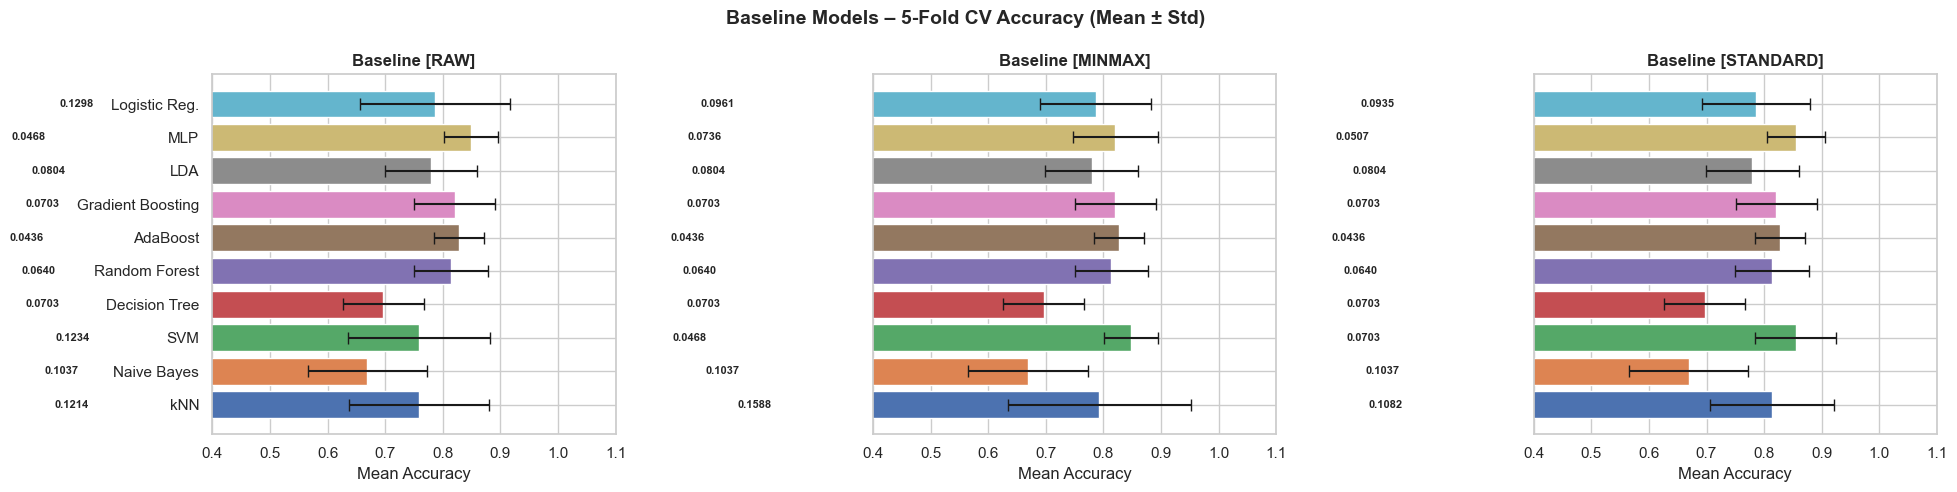

In [4]:
# Biểu đồ Baseline
colors_bar = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2',
              '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
for idx, scaler_name in enumerate(['raw', 'minmax', 'standard']):
    subset = df_baseline[df_baseline['Scaler'] == scaler_name]
    bars   = axes[idx].barh(subset['Model'], subset['Mean Acc'],
                            xerr=subset['Std Acc'], color=colors_bar,
                            edgecolor='white', capsize=4)
    axes[idx].set_title(f'Baseline [{scaler_name.upper()}]', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Mean Accuracy')
    axes[idx].set_xlim(0.4, 1.1)
    for bar, row in zip(bars, subset.itertuples()):
        axes[idx].text(row._5 + 0.005, bar.get_y() + bar.get_height()/2,
                       f'{row._5:.4f}', va='center', fontsize=8, fontweight='bold')

plt.suptitle(f'Baseline Models – {N_SPLITS}-Fold CV Accuracy (Mean ± Std)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_baseline.png'), bbox_inches='tight')
plt.show()

### 7.2 Tinh chỉnh tham số – SVM & Random Forest

In [5]:
SVM_PARAMS = {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf']}
RF_PARAMS  = {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]}

tuned_results   = []
best_estimators = {}

for scaler_name, (train_path, test_path) in FILES.items():
    X_train, _, y_train, _ = load_data(train_path, test_path)
    print(f'\n🔧 [{scaler_name.upper()}] Tinh chỉnh tham số:')

    # SVM
    svm_grid = GridSearchCV(SVC(probability=True, random_state=RANDOM_STATE),
                            SVM_PARAMS, cv=skf, scoring=SCORING)
    svm_grid.fit(X_train, y_train)
    tuned_results.append({
        'Scaler': scaler_name, 'Model': 'SVM (tuned)',
        'Loại': 'Tuned',
        'Mean Acc': round(svm_grid.best_score_, 4), 'Std Acc': 0,
        'Min Acc': 0, 'Max Acc': 0,
        'Params': str(svm_grid.best_params_),
    })
    print(f'  SVM best   : {svm_grid.best_score_:.4f} | {svm_grid.best_params_}')

    # Random Forest
    rf_grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                           RF_PARAMS, cv=skf, scoring=SCORING)
    rf_grid.fit(X_train, y_train)
    tuned_results.append({
        'Scaler': scaler_name, 'Model': 'Random Forest (tuned)',
        'Loại': 'Tuned',
        'Mean Acc': round(rf_grid.best_score_, 4), 'Std Acc': 0,
        'Min Acc': 0, 'Max Acc': 0,
        'Params': str(rf_grid.best_params_),
    })
    print(f'  RF  best   : {rf_grid.best_score_:.4f} | {rf_grid.best_params_}')

    best_estimators[scaler_name] = {
        'svm_tuned': svm_grid.best_estimator_,
        'rf_tuned' : rf_grid.best_estimator_,
    }

df_tuned = pd.DataFrame(tuned_results)
print('\n✅ Tinh chỉnh xong!')


🔧 [RAW] Tinh chỉnh tham số:


  SVM best   : 0.8690 | {'C': 100, 'kernel': 'rbf'}


  RF  best   : 0.8207 | {'max_depth': None, 'n_estimators': 50}

🔧 [MINMAX] Tinh chỉnh tham số:


  SVM best   : 0.8966 | {'C': 10, 'kernel': 'rbf'}


  RF  best   : 0.8138 | {'max_depth': None, 'n_estimators': 50}

🔧 [STANDARD] Tinh chỉnh tham số:


  SVM best   : 0.8759 | {'C': 10, 'kernel': 'rbf'}


  RF  best   : 0.8207 | {'max_depth': None, 'n_estimators': 50}

✅ Tinh chỉnh xong!


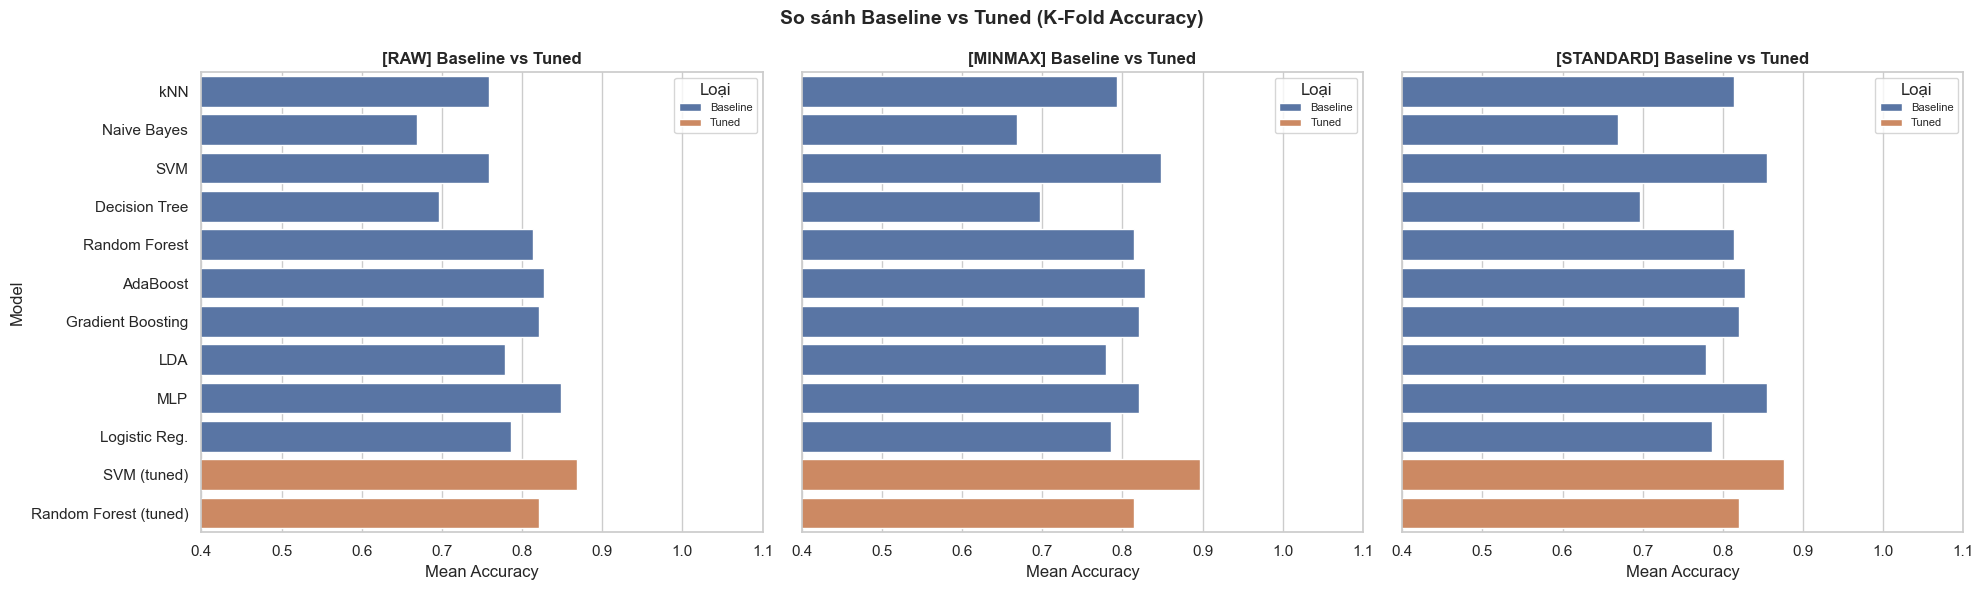

In [6]:
# So sánh Baseline vs Tuned
df_kfold_all = pd.concat([df_baseline, df_tuned], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
palette   = {'Baseline': '#4C72B0', 'Tuned': '#DD8452'}

for idx, scaler_name in enumerate(['raw', 'minmax', 'standard']):
    subset = df_kfold_all[df_kfold_all['Scaler'] == scaler_name].copy()
    sns.barplot(data=subset, x='Mean Acc', y='Model', hue='Loại',
                palette=palette, ax=axes[idx], orient='h')
    axes[idx].set_title(f'[{scaler_name.upper()}] Baseline vs Tuned', fontweight='bold')
    axes[idx].set_xlabel('Mean Accuracy')
    axes[idx].set_xlim(0.4, 1.1)
    axes[idx].legend(title='Loại', fontsize=8)

plt.suptitle('So sánh Baseline vs Tuned (K-Fold Accuracy)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_baseline_vs_tuned.png'), bbox_inches='tight')
plt.show()

## Bước 8: Kiểm nghiệm kết quả trên Test Set (Finalize Model)

In [7]:
test_results  = []
best_overall  = {'acc': 0, 'model': None, 'name': '', 'scaler': ''}
all_estimators = {}  # lưu tất cả model đã train trên full train set

for scaler_name, (train_path, test_path) in FILES.items():
    X_train, X_test, y_train, y_test = load_data(train_path, test_path)
    print(f'\n🧪 [{scaler_name.upper()}] Kiểm nghiệm trên Test Set:')
    print(f'  {"Model":<26} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1":>7} {"AUC":>7}')
    print('  ' + '-' * 65)

    # Baselines
    for name, model in get_baseline_models():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, 'predict_proba') else None
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, pos_label='M', zero_division=0)
        rec  = recall_score(y_test, y_pred, pos_label='M', zero_division=0)
        f1   = f1_score(y_test, y_pred, pos_label='M', zero_division=0)
        auc  = roc_auc_score(y_test == 'M', y_prob) if y_prob is not None else np.nan
        test_results.append({
            'Scaler': scaler_name, 'Model': name, 'Loại': 'Baseline',
            'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1-Score': round(f1,4),
            'AUC': round(auc,4) if not np.isnan(auc) else 'N/A'
        })
        print(f'  {name:<26} {acc:>7.4f} {prec:>7.4f} {rec:>7.4f} {f1:>7.4f} {auc:>7.4f}' if not np.isnan(auc) else
              f'  {name:<26} {acc:>7.4f} {prec:>7.4f} {rec:>7.4f} {f1:>7.4f} {"N/A":>7}')
        if acc > best_overall['acc']:
            best_overall = {'acc': acc, 'model': model, 'name': name, 'scaler': scaler_name}
        all_estimators[f'{scaler_name}__{name}'] = model

    # Tuned models
    for tune_name, estimator in [
        ('SVM (tuned)',          best_estimators[scaler_name]['svm_tuned']),
        ('Random Forest (tuned)',best_estimators[scaler_name]['rf_tuned']),
    ]:
        estimator.fit(X_train, y_train)
        y_pred = estimator.predict(X_test)
        y_prob = estimator.predict_proba(X_test)[:,1] if hasattr(estimator, 'predict_proba') else None
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, pos_label='M', zero_division=0)
        rec  = recall_score(y_test, y_pred, pos_label='M', zero_division=0)
        f1   = f1_score(y_test, y_pred, pos_label='M', zero_division=0)
        auc  = roc_auc_score(y_test == 'M', y_prob) if y_prob is not None else np.nan
        test_results.append({
            'Scaler': scaler_name, 'Model': tune_name, 'Loại': 'Tuned',
            'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1-Score': round(f1,4),
            'AUC': round(auc,4) if not np.isnan(auc) else 'N/A'
        })
        print(f'  {tune_name:<26} {acc:>7.4f} {prec:>7.4f} {rec:>7.4f} {f1:>7.4f} {auc:>7.4f}' if not np.isnan(auc) else
              f'  {tune_name:<26} {acc:>7.4f} {prec:>7.4f} {rec:>7.4f} {f1:>7.4f} {"N/A":>7}')
        if acc > best_overall['acc']:
            best_overall = {'acc': acc, 'model': estimator, 'name': tune_name, 'scaler': scaler_name}
        all_estimators[f'{scaler_name}__{tune_name}'] = estimator

df_test = pd.DataFrame(test_results)
print(f'\n🏆 Best: {best_overall["name"]} [{best_overall["scaler"]}] | Acc: {best_overall["acc"]:.4f}')


🧪 [RAW] Kiểm nghiệm trên Test Set:
  Model                          Acc    Prec     Rec      F1     AUC
  -----------------------------------------------------------------
  kNN                         0.7302  0.7179  0.8235  0.7671  0.2155
  Naive Bayes                 0.6190  0.7273  0.4706  0.5714  0.3114
  SVM                         0.8095  0.7619  0.9412  0.8421  0.1237
  Decision Tree               0.6190  0.6389  0.6765  0.6571  0.3859
  Random Forest               0.8571  0.8049  0.9706  0.8800  0.0624


  AdaBoost                    0.7778  0.7273  0.9412  0.8205  0.0862


  Gradient Boosting           0.8095  0.7391  1.0000  0.8500  0.0487
  LDA                         0.7302  0.7179  0.8235  0.7671  0.1988


  MLP                         0.8254  0.7949  0.9118  0.8493  0.1126
  Logistic Reg.               0.7619  0.7568  0.8235  0.7887  0.1714
  SVM (tuned)                 0.8413  0.8158  0.9118  0.8611  0.0801
  Random Forest (tuned)       0.8413  0.7857  0.9706  0.8684  0.0877

🧪 [MINMAX] Kiểm nghiệm trên Test Set:
  Model                          Acc    Prec     Rec      F1     AUC
  -----------------------------------------------------------------
  kNN                         0.7778  0.7632  0.8529  0.8056  0.1592
  Naive Bayes                 0.6190  0.7273  0.4706  0.5714  0.3114
  SVM                         0.8254  0.8108  0.8824  0.8451  0.0994
  Decision Tree               0.6190  0.6389  0.6765  0.6571  0.3859


  Random Forest               0.8571  0.8049  0.9706  0.8800  0.0619


...

  MLP                         0.7937  0.7838  0.8529  0.8169  0.1217
  Logistic Reg.               0.7460  0.7500  0.7941  0.7714  0.1653
  SVM (tuned)                 0.8889  0.8857  0.9118  0.8986  0.0720
  Random Forest (tuned)       0.8413  0.7857  0.9706  0.8684  0.0867

🧪 [STANDARD] Kiểm nghiệm trên Test Set:
  Model                          Acc    Prec     Rec      F1     AUC
  -----------------------------------------------------------------
  kNN                         0.7302  0.7073  0.8529  0.7733  0.1435
  Naive Bayes                 0.6190  0.7273  0.4706  0.5714  0.3114
  SVM                         0.7937  0.7692  0.8824  0.8219  0.1004
  Decision Tree               0.6190  0.6389  0.6765  0.6571  0.3859


  Random Forest               0.8571  0.8049  0.9706  0.8800  0.0619


  AdaBoost                    0.7778  0.7273  0.9412  0.8205  0.0862


  Gradient Boosting           0.8095  0.7391  1.0000  0.8500  0.0487
  LDA                         0.7302  0.7179  0.8235  0.7671  0.1988
  MLP                         0.8095  0.8056  0.8529  0.8286  0.0659
  Logistic Reg.               0.7460  0.7647  0.7647  0.7647  0.1592
  SVM (tuned)                 0.9048  0.8889  0.9412  0.9143  0.0720


  Random Forest (tuned)       0.8413  0.7857  0.9706  0.8684  0.0867

🏆 Best: SVM (tuned) [standard] | Acc: 0.9048


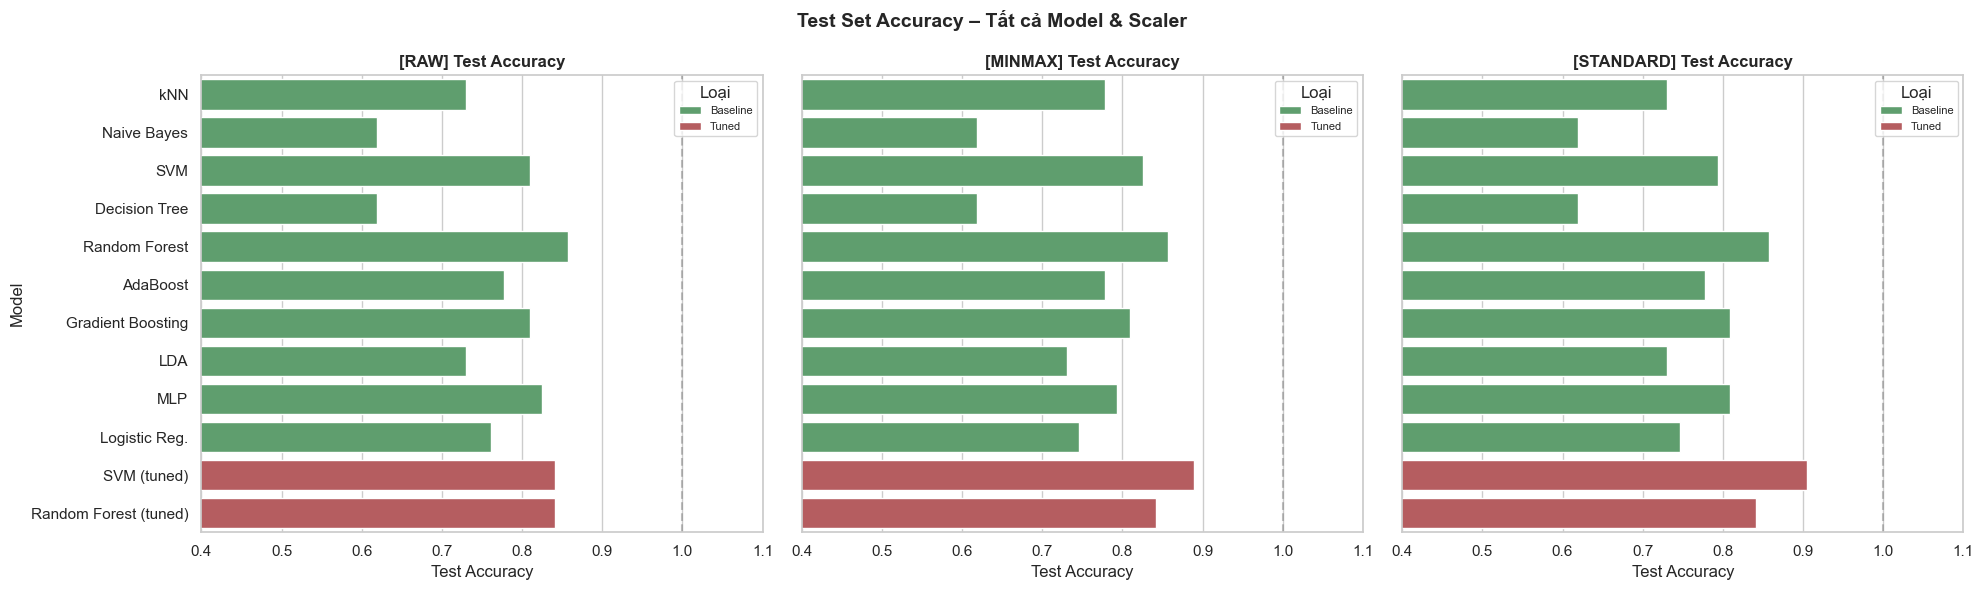

In [8]:
# Biểu đồ Test Accuracy
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
palette2  = {'Baseline': '#55A868', 'Tuned': '#C44E52'}

for idx, scaler_name in enumerate(['raw', 'minmax', 'standard']):
    subset = df_test[df_test['Scaler'] == scaler_name]
    sns.barplot(data=subset, x='Accuracy', y='Model', hue='Loại',
                palette=palette2, ax=axes[idx], orient='h')
    axes[idx].set_title(f'[{scaler_name.upper()}] Test Accuracy', fontweight='bold')
    axes[idx].set_xlabel('Test Accuracy')
    axes[idx].set_xlim(0.4, 1.1)
    axes[idx].axvline(x=1.0, color='gray', ls='--', alpha=0.5)
    axes[idx].legend(title='Loại', fontsize=8)

plt.suptitle('Test Set Accuracy – Tất cả Model & Scaler', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_test_accuracy.png'), bbox_inches='tight')
plt.show()

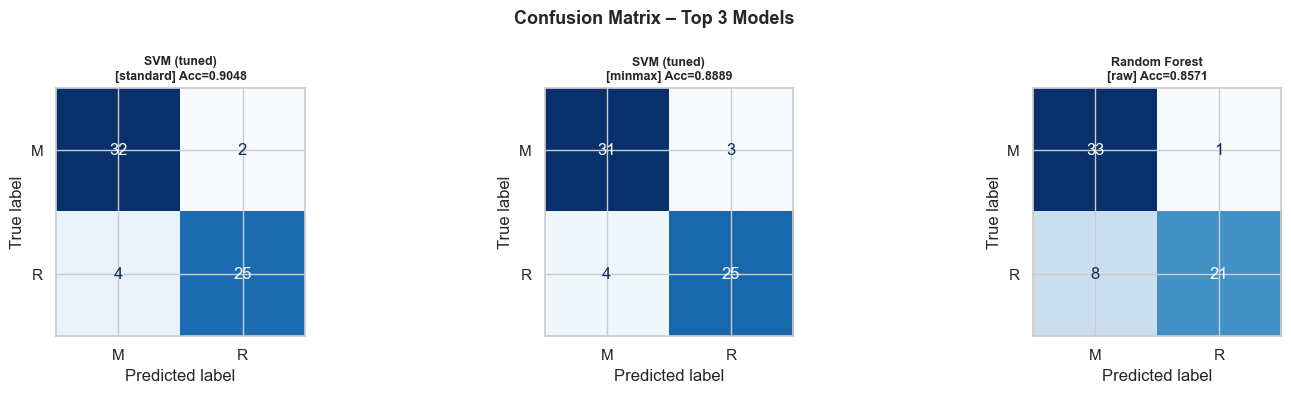


=== Classification Report: SVM (tuned) [standard] ===
              precision    recall  f1-score   support

           M       0.89      0.94      0.91        34
           R       0.93      0.86      0.89        29

    accuracy                           0.90        63
   macro avg       0.91      0.90      0.90        63
weighted avg       0.91      0.90      0.90        63



In [9]:
# Confusion Matrix – top 3 model tốt nhất
top3_rows = df_test.nlargest(3, 'Accuracy')[['Scaler','Model']]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (_, row) in zip(axes, top3_rows.iterrows()):
    sn, mn = row['Scaler'], row['Model']
    X_train, X_test, y_train, y_test = load_data(*FILES[sn])
    est = all_estimators[f'{sn}__{mn}']
    est.fit(X_train, y_train)
    y_pred  = est.predict(X_test)
    classes = np.unique(y_test)
    acc_val = df_test[(df_test['Scaler']==sn) & (df_test['Model']==mn)]['Accuracy'].values[0]
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{mn}\n[{sn}] Acc={acc_val}', fontsize=9, fontweight='bold')

plt.suptitle('Confusion Matrix – Top 3 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_confusion_matrix.png'), bbox_inches='tight')
plt.show()

# Classification report của best model
best_sn = best_overall['scaler']
X_train, X_test, y_train, y_test = load_data(*FILES[best_sn])
best_overall['model'].fit(X_train, y_train)
y_pred_best = best_overall['model'].predict(X_test)
print(f'\n=== Classification Report: {best_overall["name"]} [{best_sn}] ===')
print(classification_report(y_test, y_pred_best))

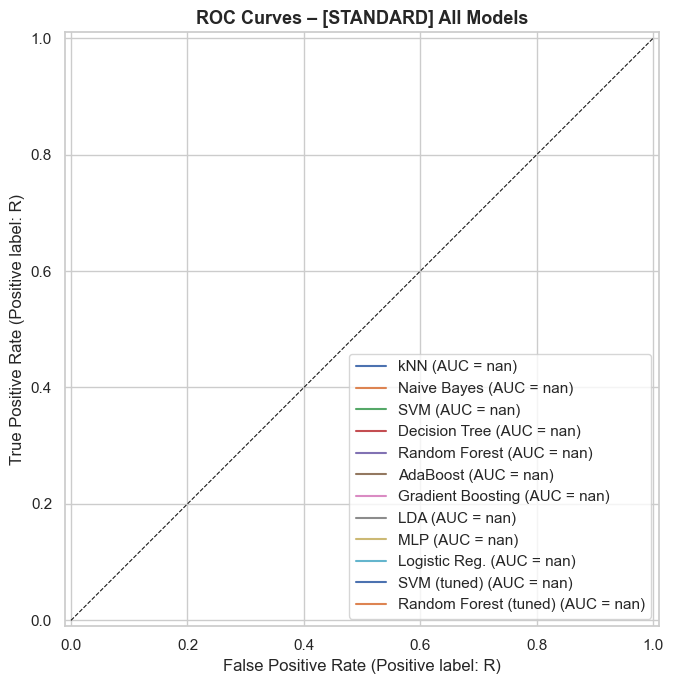

In [10]:
# ROC Curves – best scaler, tất cả model có predict_proba
best_sn = best_overall['scaler']
X_train, X_test, y_train, y_test = load_data(*FILES[best_sn])

fig, ax = plt.subplots(figsize=(9, 7))
for key, est in all_estimators.items():
    if not key.startswith(best_sn):
        continue
    if not hasattr(est, 'predict_proba'):
        continue
    model_label = key.replace(f'{best_sn}__', '')
    est.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(est, X_test, y_test == 'M', ax=ax, name=model_label)
ax.plot([0,1],[0,1],'k--', lw=0.8)
ax.set_title(f'ROC Curves – [{best_sn.upper()}] All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_roc_curves.png'), bbox_inches='tight')
plt.show()

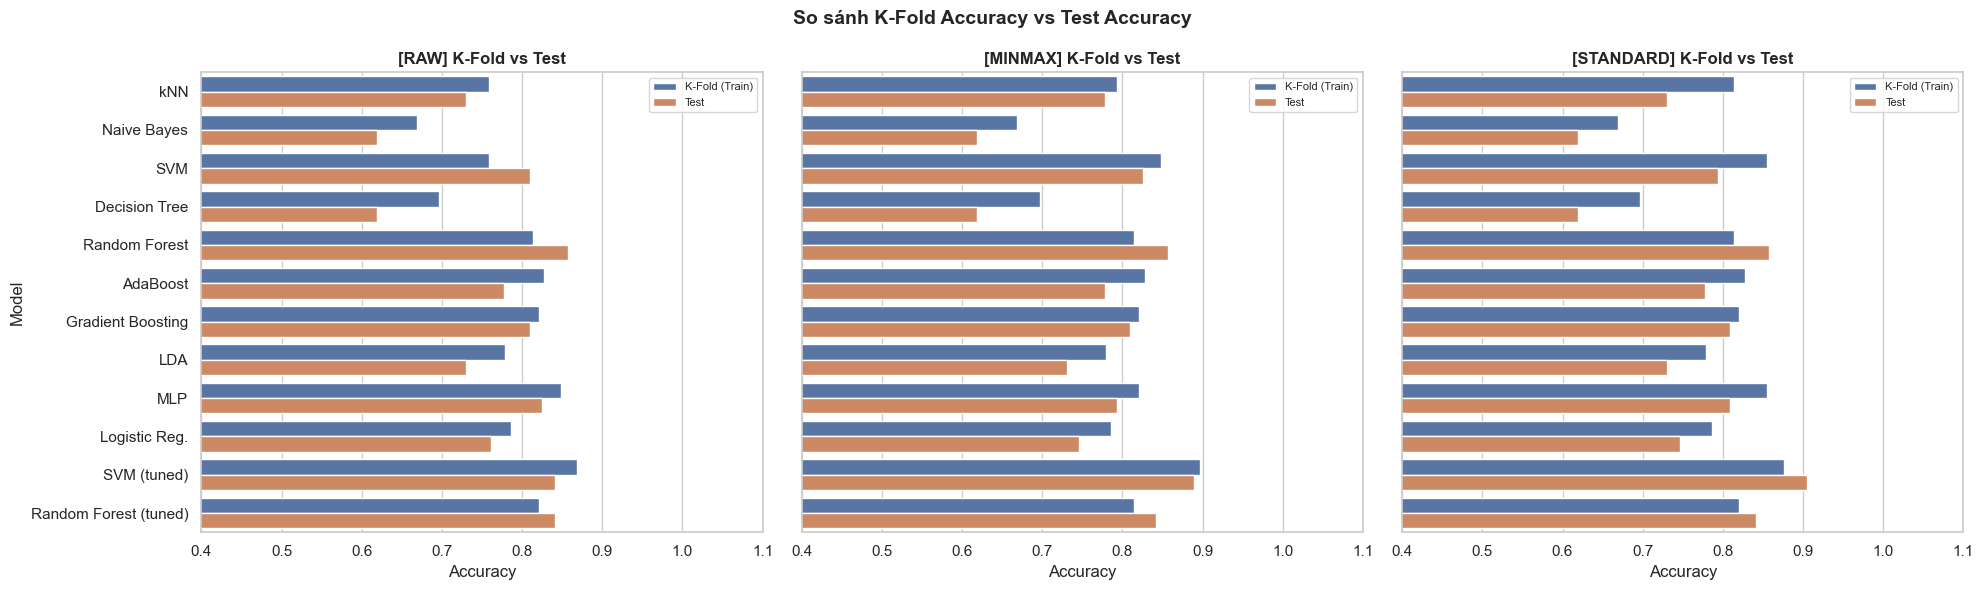

In [11]:
# So sánh K-Fold vs Test
df_kf_cmp   = df_kfold_all[['Scaler','Model','Mean Acc']].rename(columns={'Mean Acc':'Accuracy'})
df_kf_cmp['Phase'] = 'K-Fold (Train)'
df_te_cmp   = df_test[['Scaler','Model','Accuracy']].copy()
df_te_cmp['Phase'] = 'Test'
df_compare  = pd.concat([df_kf_cmp, df_te_cmp], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
for idx, scaler_name in enumerate(['raw', 'minmax', 'standard']):
    subset = df_compare[df_compare['Scaler'] == scaler_name]
    sns.barplot(data=subset, x='Accuracy', y='Model', hue='Phase',
                palette={'K-Fold (Train)': '#4C72B0', 'Test': '#DD8452'},
                ax=axes[idx], orient='h')
    axes[idx].set_title(f'[{scaler_name.upper()}] K-Fold vs Test', fontweight='bold')
    axes[idx].set_xlim(0.4, 1.1)
    axes[idx].legend(fontsize=8)

plt.suptitle('So sánh K-Fold Accuracy vs Test Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_kfold_vs_test.png'), bbox_inches='tight')
plt.show()

## Lưu kết quả thí nghiệm

In [12]:
# ── Lưu tất cả model vào model/ ─────────────────────────
os.makedirs(MODEL_DIR, exist_ok=True)
for key, est in all_estimators.items():
    fname = key.replace(' ','_').replace('/','').replace('(','').replace(')','') + '.pkl'
    fpath = os.path.join(MODEL_DIR, fname)
    with open(fpath, 'wb') as f:
        pickle.dump(est, f)

# Lưu best model với tên cố định
best_key = f"{best_overall['scaler']}__{best_overall['name']}"
model_path = os.path.join(MODEL_DIR, f'best_model_{best_overall["scaler"]}.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(best_overall['model'], f)
print(f'💾 Đã lưu best model: {os.path.basename(model_path)}')
print(f'💾 Đã lưu {len(all_estimators)} models vào {MODEL_DIR}/')

# ── Ghi train_log.xlsx ──────────────────────────────────
df_exp_info = pd.DataFrame([{
    'Thời gian'    : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Dataset'      : 'sonar.csv',
    'K-Fold'       : N_SPLITS,
    'Test size'    : '30%',
    'Best model'   : best_overall['name'],
    'Best scaler'  : best_overall['scaler'],
    'Best Test Acc': best_overall['acc'],
    'Model file'   : model_path,
}])

# Ghi train_log.xlsx – ghi đè toàn bộ file (tránh lỗi if_sheet_exists)
if os.path.exists(TRAIN_LOG):
    try:
        df_old     = pd.read_excel(TRAIN_LOG, sheet_name='Thong_tin_TN')
        df_history = pd.concat([df_old, df_exp_info], ignore_index=True)
        is_new     = False
    except Exception:
        df_history = df_exp_info
        is_new     = True
else:
    df_history = df_exp_info
    is_new     = True

with pd.ExcelWriter(TRAIN_LOG, engine='openpyxl', mode='w') as writer:
    df_history.to_excel(writer,   sheet_name='Thong_tin_TN',   index=False)
    df_baseline.to_excel(writer,  sheet_name='Baseline_KFold', index=False)
    df_tuned.to_excel(writer,     sheet_name='Tuned_KFold',    index=False)
    df_test.to_excel(writer,      sheet_name='Test_Results',   index=False)
    df_kfold_all.to_excel(writer, sheet_name='Tat_ca_KFold',   index=False)

label = 'Tao file moi' if is_new else 'Cap nhat file'
print(f'{label}: {TRAIN_LOG}')

💾 Đã lưu best model: best_model_standard.pkl
💾 Đã lưu 36 models vào D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\model/


Cap nhat file: D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\exps_\train_log.xlsx


## Tổng kết thực nghiệm

In [13]:
print('=' * 60)
print('TỔNG KẾT THỰC NGHIỆM - SONAR RETURNS CLASSIFICATION')
print('=' * 60)
print(f'\n📌 Cấu hình thực nghiệm:')
print(f'   K-Fold     : {N_SPLITS} folds (Stratified)')
print(f'   Scoring    : {SCORING}')
print(f'   Scalers    : raw, minmax, standard')
print(f'\n📌 Số model đã train:')
print(f'   Baseline   : 10 models x 3 scalers = 30')
print(f'   Tuned      :  2 models x 3 scalers =  6')
print(f'   Tổng cộng  : 36 models')
print(f'\n🏆 Model tốt nhất:')
print(f'   Tên        : {best_overall["name"]}')
print(f'   Scaler     : {best_overall["scaler"]}')
print(f'   Test Acc   : {best_overall["acc"]:.4f}')
print(f'   Lưu tại    : {model_path}')
print(f'\n📁 File kết quả:')
print(f'   {TRAIN_LOG}')
print('=' * 60)

TỔNG KẾT THỰC NGHIỆM - SONAR RETURNS CLASSIFICATION

📌 Cấu hình thực nghiệm:
   K-Fold     : 5 folds (Stratified)
   Scoring    : accuracy
   Scalers    : raw, minmax, standard

📌 Số model đã train:
   Baseline   : 10 models x 3 scalers = 30
   Tuned      :  2 models x 3 scalers =  6
   Tổng cộng  : 36 models

🏆 Model tốt nhất:
   Tên        : SVM (tuned)
   Scaler     : standard
   Test Acc   : 0.9048
   Lưu tại    : D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\model\best_model_standard.pkl

📁 File kết quả:
   D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\exps_\train_log.xlsx
